In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product
import lightgbm as lgb
from sklearn.metrics import mean_squared_error


In [3]:
df = pd.read_csv('../data/final_data/final_df.csv')

---

## FE

In [54]:
cat_features = ['shop_id', 'item_id', 'item_category_id']

---

In [4]:
df

,date_block_num,shop_id,item_id,item_category_id,item_cnt,transaction,item_cnt_mean,item_price_mean,revenue,season,...,item_cnt_lag_3,item_cnt_lag_12,item_trend,price_increase,price_decrease,has_holiday,weekend_count,month_start_weekday,shop_avg_sales_3m,cat_avg_sales_3m
0,0,59,22154,37.0,1.0,1.0,1.0,999.0,999.0,Winter,...,0.0,0.0,0.0,0,0,1,8,1,0.044953,1.527387
1,0,59,2552,0.0,0.0,0.0,0.0,0.0,0.0,Winter,...,0.0,0.0,0.0,0,0,1,8,1,0.044953,0.000000
2,0,59,2554,0.0,0.0,0.0,0.0,0.0,0.0,Winter,...,0.0,0.0,0.0,0,0,1,8,1,0.044953,0.000000
3,0,59,2555,0.0,0.0,0.0,0.0,0.0,0.0,Winter,...,0.0,0.0,0.0,0,0,1,8,1,0.044953,0.000000
4,0,59,2564,0.0,0.0,0.0,0.0,0.0,0.0,Winter,...,0.0,0.0,0.0,0,0,1,8,1,0.044953,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44484235,33,36,8428,0.0,0.0,0.0,0.0,0.0,0.0,Autumn,...,0.0,0.0,0.0,0,0,0,9,3,0.003818,0.000000
44484236,33,36,7903,0.0,0.0,0.0,0.0,0.0,0.0,Autumn,...,0.0,0.0,0.0,0,0,0,9,3,0.003818,0.000000
44484237,33,36,7610,0.0,0.0,0.0,0.0,0.0,0.0,Autumn,...,0.0,0.0,0.0,0,0,0,9,3,0.003818,0.000000
44484238,33,36,7635,0.0,0.0,0.0,0.0,0.0,0.0,Autumn,...,0.0,0.0,0.0,0,0,0,9,3,0.003818,0.000000


In [55]:
train_set = df.query('date_block_num >= 3 and date_block_num < 33').copy()
validation_set = df.query('date_block_num == 33').copy()

In [34]:
cols_to_drop = ['item_cnt',
 'revenue',
 'transaction',
 'item_cnt_mean',
 'item_price_mean',
 'item_trend',
 'date_block_num',
 'item_cnt_mean',
 'item_price_mean',
 'item_trend',
 'item_category_id']

In [35]:
X_train = train_set.drop(cols_to_drop, axis=1)
y_train = train_set['item_cnt']

In [36]:
X_val = validation_set.drop(cols_to_drop, axis=1)
y_val = validation_set['item_cnt']

In [38]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 39250800 entries, 3925080 to 43175879
Data columns (total 15 columns):
 #   Column               Dtype  
---  ------               -----  
 0   shop_id              int64  
 1   item_id              int64  
 2   season               str    
 3   month                int64  
 4   item_cnt_lag_1       float64
 5   item_cnt_lag_2       float64
 6   item_cnt_lag_3       float64
 7   item_cnt_lag_12      float64
 8   price_increase       int64  
 9   price_decrease       int64  
 10  has_holiday          int64  
 11  weekend_count        int64  
 12  month_start_weekday  int64  
 13  shop_avg_sales_3m    float64
 14  cat_avg_sales_3m     float64
dtypes: float64(6), int64(8), str(1)
memory usage: 4.4 GB


In [40]:
cat_features = ['shop_id', 'item_id', 'season', 'month']

In [41]:
for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

---

In [42]:
params = {
    'objective': 'regression',      
    'metric': 'rmse',               
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,           
    'num_leaves': 31,               
    'verbose': -1,                  
    'seed': 42,
   
    'num_leaves': 15,         
    'max_depth': 6,           
    'min_data_in_leaf': 50,   
    

    'learning_rate': 0.05,         
    
    
    'lambda_l1': 0.1,
    'lambda_l2': 0.5,
    
    
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'feature_fraction': 0.8,
    
    
    'min_gain_to_split': 0.01,
    'max_bin': 255,
    
    
    'n_jobs': -1,
     
}

In [43]:
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_features)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=cat_features)

In [44]:
model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_val],
    valid_names=['validation'],
    num_boost_round=2000,         
    callbacks=[
        lgb.early_stopping(stopping_rounds=100), 
        lgb.log_evaluation(50)                  
    ]
    
)

Training until validation scores don't improve for 100 rounds
[50]	validation's rmse: 1.01843
[100]	validation's rmse: 0.985413
Early stopping, best iteration is:
[12]	validation's rmse: 0.957109


In [45]:
y_pred_val = model.predict(X_val)
rmse = mean_squared_error(y_val, y_pred_val)

In [46]:
(rmse)**0.5

0.9571091274431578

In [47]:
best_iteration = model.best_iteration

In [48]:
model.best_iteration

12

---

## FS

In [24]:
import shap

/Users/filimono/Documents/Innowise/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
X_sample = X_train.tail(2000)

In [50]:
explainer = shap.TreeExplainer(model)

In [51]:
shap_values = explainer.shap_values(X_sample)

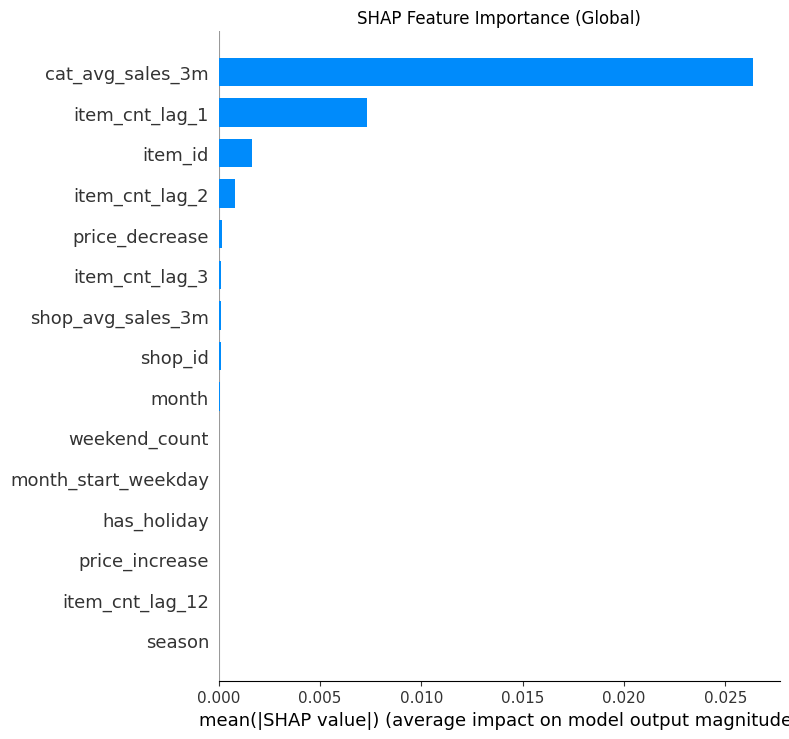

In [52]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150, bbox_inches="tight")



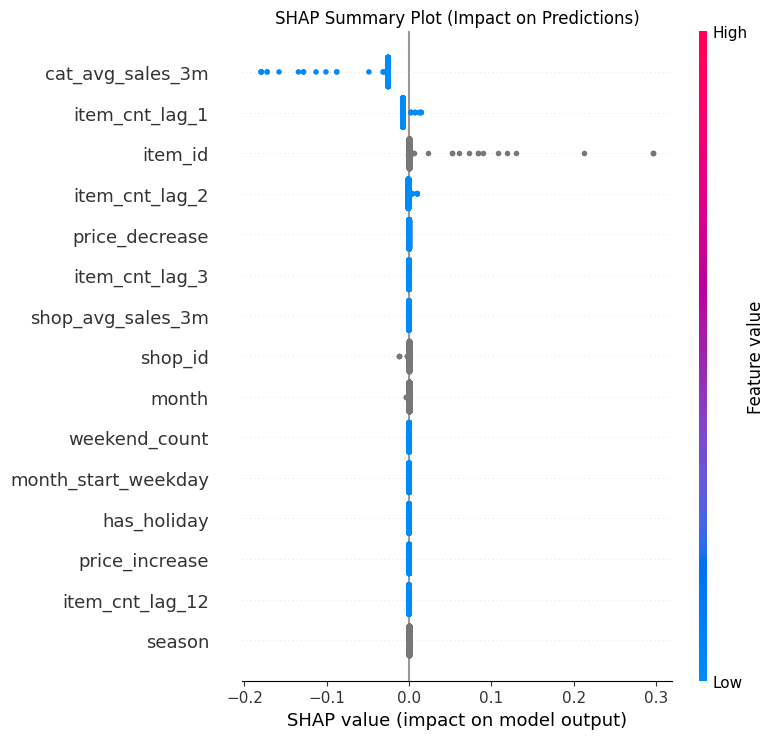

In [53]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot (Impact on Predictions)")
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=150, bbox_inches="tight")


---

In [30]:
import xgboost as xgb

In [31]:
params_xgb = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    'seed': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

In [32]:
from sklearn.preprocessing import LabelEncoder

In [33]:

for col in ['shop_id', 'item_id', 'item_category_id']:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

model_xgb = xgb.train(
    params_xgb,
    dtrain,
    num_boost_round=2000,
    evals=[(dval, 'val')],
    early_stopping_rounds=100,
    verbose_eval=100
)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:season: category, month: category

In [ ]:
y_pred_xgb = model_xgb.predict(dval)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

---

In [16]:
final_train_set = df

In [25]:
X_train_full = final_train_set.drop(cols_to_drop, axis=1)
y_train_full = final_train_set['item_cnt']
y_train_full_clipped = np.clip(y_train_full, 0, 20)  

In [30]:
cols_to_test_drop = [
    'ID', 'item_cnt', 'revenue', 'transaction', 
    'item_cnt_mean', 'item_price_mean', 'item_trend', 'date_block_num'
]

In [32]:
for col in cat_features:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].astype('category')


In [48]:
lgb_train_full = lgb.Dataset(X_train_full, y_train_full)


In [49]:
model_final = lgb.train(
    params,
    lgb_train_full,                    
    num_boost_round=best_iteration,    
    valid_sets=None,                   
    callbacks=[lgb.log_evaluation(100)]
)

In [69]:
test = pd.read_csv('../data/final_data/test.csv')


test['month'] = 11
test['season'] = 'Spring'
test['has_holiday'] = 1
test['weekend_count'] = 9
test['month_start_weekday'] = 6


item_info = df[['item_id', 'item_category_id', 'category_tier']].drop_duplicates(subset=['item_id'])
shop_info = df[['shop_id', 'shop_tier']].drop_duplicates(subset=['shop_id'])

test = pd.merge(test, item_info, on='item_id', how='left')
test = pd.merge(test, shop_info, on='shop_id', how='left')

lag_1_df = df[df['date_block_num'] == 33][['shop_id', 'item_id', 'item_cnt']].drop_duplicates(subset=['shop_id', 'item_id'])
lag_1_df.columns = ['shop_id', 'item_id', 'item_cnt_lag_1']
test = pd.merge(test, lag_1_df, on=['shop_id', 'item_id'], how='left')

lag_2_df = df[df['date_block_num'] == 32][['shop_id', 'item_id', 'item_cnt']].drop_duplicates(subset=['shop_id', 'item_id'])
lag_2_df.columns = ['shop_id', 'item_id', 'item_cnt_lag_2']
test = pd.merge(test, lag_2_df, on=['shop_id', 'item_id'], how='left')

lag_3_df = df[df['date_block_num'] == 31][['shop_id', 'item_id', 'item_cnt']].drop_duplicates(subset=['shop_id', 'item_id'])
lag_3_df.columns = ['shop_id', 'item_id', 'item_cnt_lag_3']
test = pd.merge(test, lag_3_df, on=['shop_id', 'item_id'], how='left')

price_df = df[df['date_block_num'] == 33][['shop_id', 'item_id', 'price_increase', 'price_decrease']].drop_duplicates(subset=['shop_id', 'item_id'])
test = pd.merge(test, price_df, on=['shop_id', 'item_id'], how='left')


test['item_cnt_lag_1'] = test['item_cnt_lag_1'].fillna(0)
test['item_cnt_lag_2'] = test['item_cnt_lag_2'].fillna(0)
test['item_cnt_lag_3'] = test['item_cnt_lag_3'].fillna(0)
test['price_increase'] = test['price_increase'].fillna(0)
test['price_decrease'] = test['price_decrease'].fillna(0)
test['item_category_id'] = test['item_category_id'].fillna(0)
test['shop_tier'] = test['shop_tier'].fillna('Mid') 
test['category_tier'] = test['category_tier'].fillna('Mid')


X_test = test[X_train.columns]

In [64]:
X_train_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 44484240 entries, 0 to 44484239
Data columns (total 15 columns):
 #   Column               Dtype   
---  ------               -----   
 0   shop_id              category
 1   item_id              category
 2   item_category_id     category
 3   season               category
 4   month                category
 5   item_cnt_lag_1       float64 
 6   item_cnt_lag_2       float64 
 7   item_cnt_lag_3       float64 
 8   price_increase       int64   
 9   price_decrease       int64   
 10  has_holiday          int64   
 11  weekend_count        int64   
 12  month_start_weekday  int64   
 13  shop_tier            category
 14  category_tier        category
dtypes: category(7), float64(3), int64(5)
memory usage: 3.0 GB


In [65]:
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 214200 entries, 0 to 214199
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   shop_id              214200 non-null  category
 1   item_id              214200 non-null  category
 2   item_category_id     214200 non-null  category
 3   season               214200 non-null  category
 4   month                214200 non-null  category
 5   item_cnt_lag_1       214200 non-null  float64 
 6   item_cnt_lag_2       214200 non-null  float64 
 7   item_cnt_lag_3       214200 non-null  float64 
 8   price_increase       214200 non-null  float64 
 9   price_decrease       214200 non-null  float64 
 10  has_holiday          214200 non-null  int64   
 11  weekend_count        214200 non-null  int64   
 12  month_start_weekday  214200 non-null  int64   
 13  shop_tier            214200 non-null  category
 14  category_tier        214200 non-null  category
dtypes: category

In [63]:
for col in cat_features:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

In [66]:
y_pred_test = model_final.predict(X_test)

In [67]:
submission = pd.DataFrame({
    'ID': test['ID'],
    'item_cnt_month': y_pred_test
})

In [68]:
submission.to_csv('../data/submission/final_submission.csv', index=False)